# Analysis and Visualizations of Experiment 2 Results

The analysis from this notebook will make up the tables, figures and results for Experiment 2

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('../Experiment 1/dataset/experiment2_result.csv')

display(df)

,Experiment,Heuristic,Movement,Grid_Size,Execution_Time,Nodes_Expanded,Path_Length,Optimality_Ratio
0,2,Manhattan,4-dir,50x50,6.519±3.600,627.933±288.055,99.400±0.968,2.028±0.020
1,2,Manhattan,8-dir,50x50,1.406±0.482,62.733±6.335,57.200±2.709,1.161±0.061
2,2,Euclidean,4-dir,50x50,4.845±2.465,579.433±263.588,101.933±3.183,2.080±0.065
3,2,Euclidean,8-dir,50x50,1.038±0.171,75.233±14.388,59.800±2.524,1.220±0.052
4,2,Chebyshev,4-dir,50x50,10.677±2.183,1292.333±139.295,100.733±2.664,2.055±0.054
5,2,Chebyshev,8-dir,50x50,9.229±1.838,893.400±64.004,57.767±1.569,1.179±0.032


#### Extract means from data, and create tables

The tables created will be shown in Table 4.2.2, 4.2.3 and 4.2.4 (See Paper)

In [4]:
df = pd.read_csv('../Experiment 1/dataset/experiment2_result.csv')

# Extract numeric means
df['Nodes_Mean'] = df['Nodes_Expanded'].str.split('±').str[0].astype(float)
df['Time_Mean'] = df['Execution_Time'].str.split('±').str[0].astype(float)
df['Path_Mean'] = df['Path_Length'].str.split('±').str[0].astype(float)
df['Ratio_Mean'] = df['Optimality_Ratio'].str.split('±').str[0].astype(float)

def create_table(value_col_mean, value_col_raw):
    # Pivot to get raw strings for the display table
    pivot_display = df.pivot(index='Movement', columns='Heuristic', values=value_col_raw)
    
    # Pivot to get numeric means to determine optimal
    pivot_numeric = df.pivot(index='Movement', columns='Heuristic', values=value_col_mean)
    
    # Identify Optimal Heuristic (min mean)
    pivot_display['Optimal Heuristic'] = pivot_numeric.idxmin(axis=1)
    
    return pivot_display[['Manhattan', 'Euclidean', 'Chebyshev', 'Optimal Heuristic']]

table_runtime = create_table('Time_Mean', 'Execution_Time')
table_path = create_table('Path_Mean', 'Optimality_Ratio')
table_nodes = create_table('Nodes_Mean', 'Nodes_Expanded')

print("Heuristic effectiveness on Runtime Analysis Table")
display(table_runtime)
print("\n Heuristic effectiveness on Path Cost Analysis Table")
display(table_path)
print("\n Heuristic effectiveness on Node Expansion Analysis Table")
display(table_nodes)

Heuristic effectiveness on Runtime Analysis Table


Heuristic,Manhattan,Euclidean,Chebyshev,Optimal Heuristic
Movement,,,,
4-dir,6.519±3.600,4.845±2.465,10.677±2.183,Euclidean
8-dir,1.406±0.482,1.038±0.171,9.229±1.838,Euclidean



 Heuristic effectiveness on Path Cost Analysis Table


Heuristic,Manhattan,Euclidean,Chebyshev,Optimal Heuristic
Movement,,,,
4-dir,2.028±0.020,2.080±0.065,2.055±0.054,Manhattan
8-dir,1.161±0.061,1.220±0.052,1.179±0.032,Manhattan



 Heuristic effectiveness on Node Expansion Analysis Table


Heuristic,Manhattan,Euclidean,Chebyshev,Optimal Heuristic
Movement,,,,
4-dir,627.933±288.055,579.433±263.588,1292.333±139.295,Euclidean
8-dir,62.733±6.335,75.233±14.388,893.400±64.004,Manhattan


## Visualizations

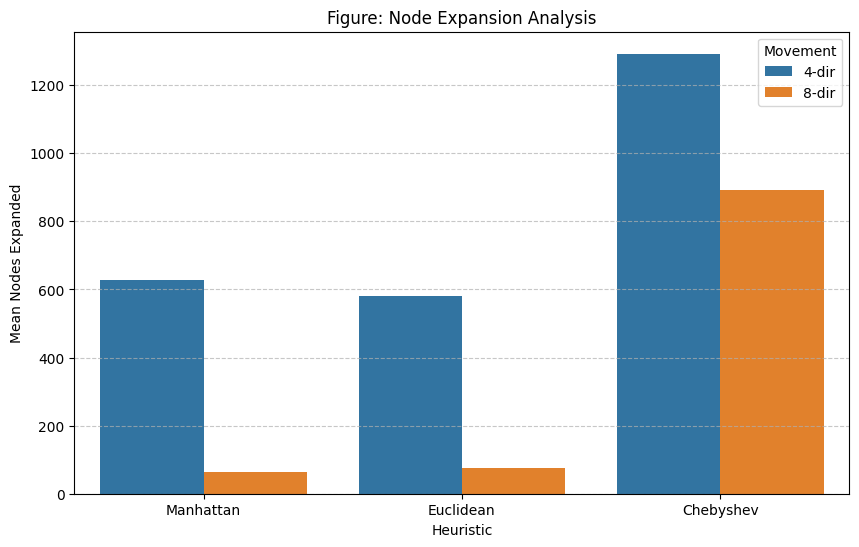

In [5]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Heuristic', y='Nodes_Mean', hue='Movement')
plt.title('Figure: Node Expansion Analysis')
plt.ylabel('Mean Nodes Expanded')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

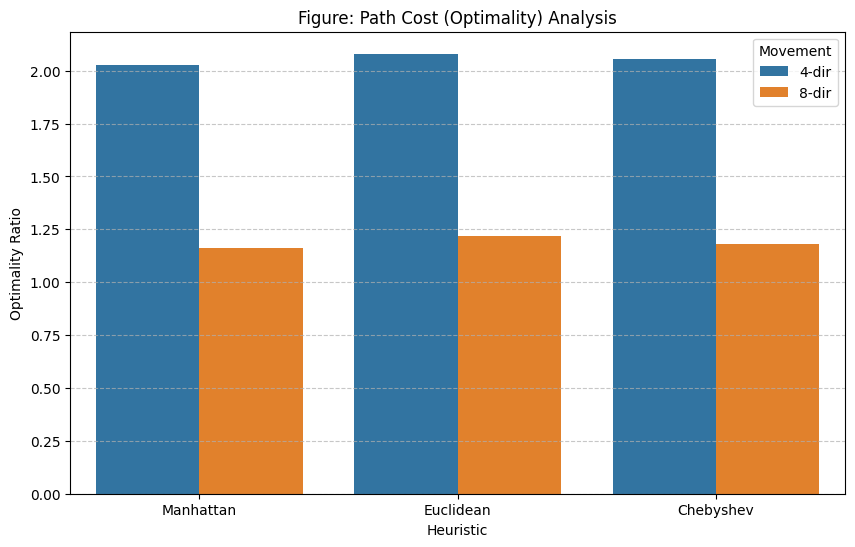

In [11]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Heuristic', y='Ratio_Mean', hue='Movement')
plt.title('Figure: Path Cost (Optimality) Analysis')
plt.ylabel('Optimality Ratio')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

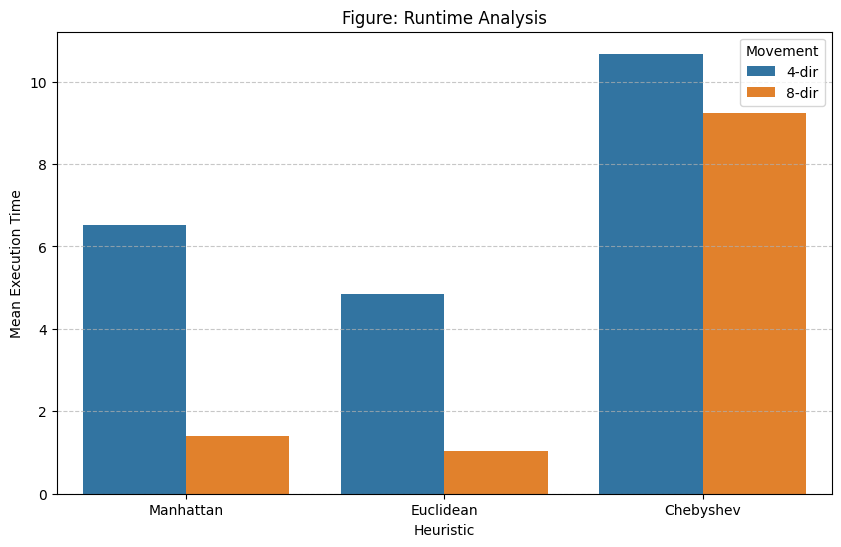

In [12]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Heuristic', y='Time_Mean', hue='Movement')
plt.title('Figure: Runtime Analysis')
plt.ylabel('Mean Execution Time')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

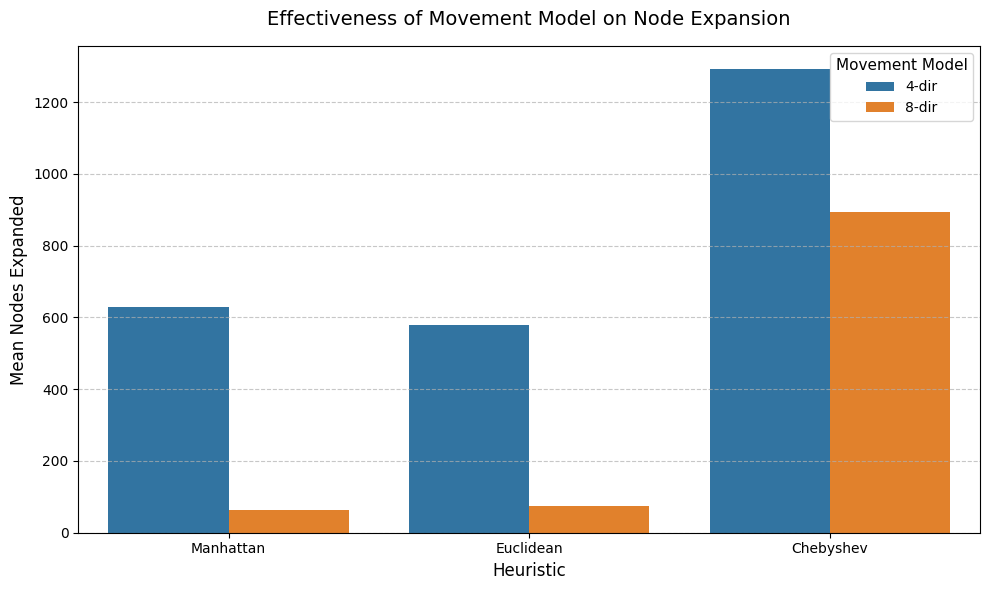

In [8]:
# Extract means for the plot
df['Nodes'] = df['Nodes_Expanded'].apply(lambda x: float(x.split('±')[0]))

# Create the plot
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Heuristic', y='Nodes', hue='Movement')

# Formatting
plt.title('Effectiveness of Movement Model on Node Expansion', fontsize=14, pad=15)
plt.ylabel('Mean Nodes Expanded', fontsize=12)
plt.xlabel('Heuristic', fontsize=12)
plt.legend(title='Movement Model', fontsize=10, title_fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [9]:
df['Mean_Path'] = df['Path_Length'].apply(lambda x: float(x.split('±')[0]))
df['Std_Path'] = df['Path_Length'].apply(lambda x: float(x.split('±')[1]))
df['Mean_Ratio'] = df['Optimality_Ratio'].apply(lambda x: float(x.split('±')[0]))
df['Std_Ratio'] = df['Optimality_Ratio'].apply(lambda x: float(x.split('±')[1]))

# Prepare Summary Table
table_df = df.pivot(index='Heuristic', columns='Movement', values='Mean_Path').reset_index()
display(table_df)

Movement,Heuristic,4-dir,8-dir
0,Chebyshev,100.733,57.767
1,Euclidean,101.933,59.800
2,Manhattan,99.400,57.200


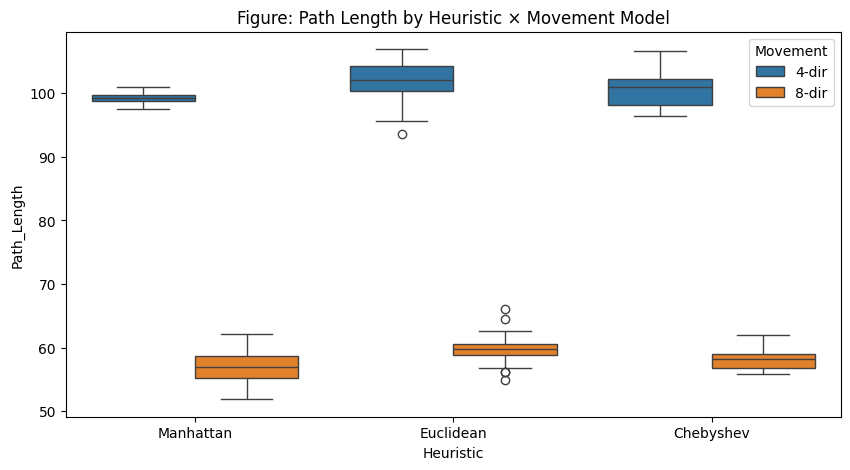

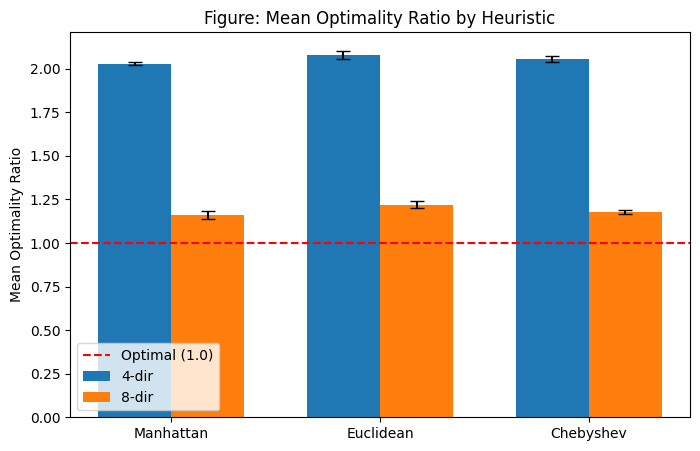

In [ ]:
# --- Plot 1: Boxplot ---
np.random.seed(42)
box_data = []
for _, row in df.iterrows():
    samples = np.random.normal(row['Mean_Path'], row['Std_Path'], 30)
    for s in samples:
        box_data.append({'Heuristic': row['Heuristic'], 'Movement': row['Movement'], 'Path_Length': s})
box_df = pd.DataFrame(box_data)

plt.figure(figsize=(10, 5))
sns.boxplot(data=box_df, x='Heuristic', y='Path_Length', hue='Movement')
plt.title('Figure: Path Length by Heuristic × Movement Model')
plt.show()

# --- Plot 2: Bar Chart ---
x = np.arange(len(df['Heuristic'].unique()))
width = 0.35
plt.figure(figsize=(8, 5))
for i, movement in enumerate(['4-dir', '8-dir']):
    subset = df[df['Movement'] == movement]
    plt.bar(x + (i - 0.5) * width, subset['Mean_Ratio'], width, 
            yerr=1.96 * (subset['Std_Ratio'] / np.sqrt(30)), label=movement, capsize=5)

plt.axhline(y=1.0, color='r', linestyle='--', label='Optimal (1.0)')
plt.xticks(x, df['Heuristic'].unique())
plt.title('Figure: Mean Optimality Ratio by Heuristic')
plt.ylabel('Mean Optimality Ratio')
plt.legend()
plt.show()